# Pulling Real Stock & FX Data – My Finance BA Version (2026 Update)
Forked from JP Morgan Chase python-training repo  
Customized by S33mi ( March 2026)  
Goal: Fetch live stock prices, stock exchange data, and USD exchange rates using yfinance (pandas_datareader removed – it's outdated).  
Skills: Multi-ticker fetching, returns calculation, interactive charts, CSV export – daily tools for business analysts.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

import yfinance as yf
import pandas as pd
import numpy as np
from ipywidgets import interact, Text
from datetime import datetime

pd.set_option('display.float_format', '{:.4f}'.format)

### Modern Stock Data Fetcher with yfinance (Recommended for 2026)

/tmp/ipykernel_443/2198446541.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, progress=False)['Close']


Ticker,AAPL,FROTO.IS,JPM,MSFT,TSLA
Date,,,,,
2026-03-16,252.8200,105.6000,286.1600,399.9500,395.5600
2026-03-17,254.2300,107.9000,286.8900,399.4100,399.2700
2026-03-18,249.9400,105.7000,287.7400,391.7900,392.7800
2026-03-19,248.9600,109.8000,287.9700,389.0200,380.3000
2026-03-20,247.9900,NaN,286.5600,381.8700,367.9600


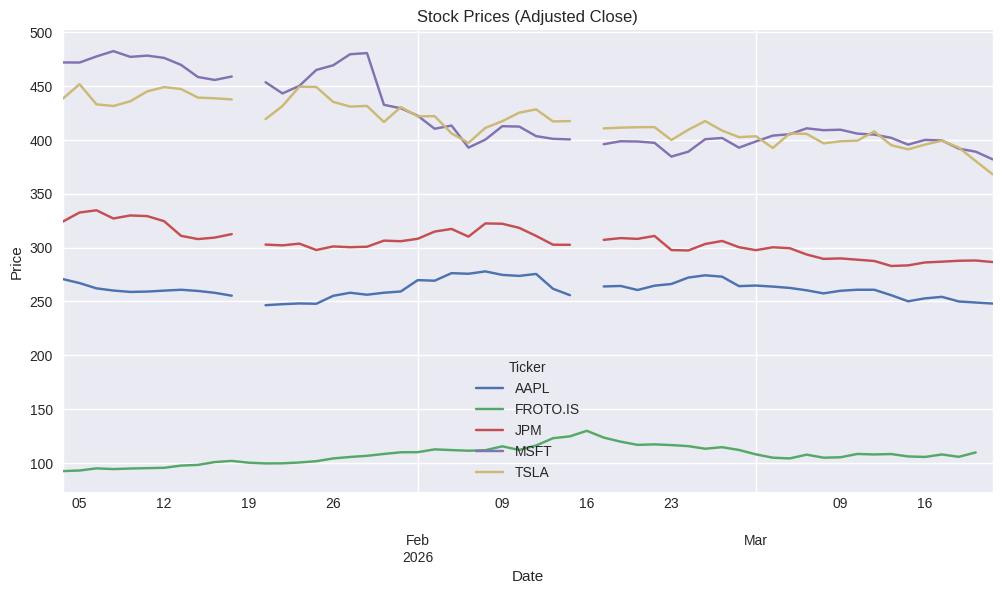

In [10]:
def get_stock_data(tickers, start="2026-01-01", end=None):
    if end is None:
        end = datetime.today().strftime('%Y-%m-%d')
    data = yf.download(tickers, start=start, end=end, progress=False)['Close']
    return data

# Example: Global stocks
tickers = ['JPM', 'FROTO.IS', 'AAPL', 'MSFT', 'TSLA'] # FROTO • Istanbul based stock Ford Otomotiv Sanayi AS
df = get_stock_data(tickers)
display(df.tail(5))
df.plot(figsize=(12, 6), title='Stock Prices (Adjusted Close)')
plt.ylabel('Price')
plt.show()

## Global Data: USD/EUR Exchange Rate + Global Stocks

/tmp/ipykernel_443/2198446541.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, progress=False)['Close']


Ticker,EURGBP=X,USDEUR=X,USDGBP=X
Date,,,
2026-03-16,0.8631,0.8745,0.7548
2026-03-17,0.8636,0.8696,0.7511
2026-03-18,0.8638,0.8666,0.7485
2026-03-19,0.8642,0.8723,0.7539
2026-03-20,0.8623,0.8639,0.7493


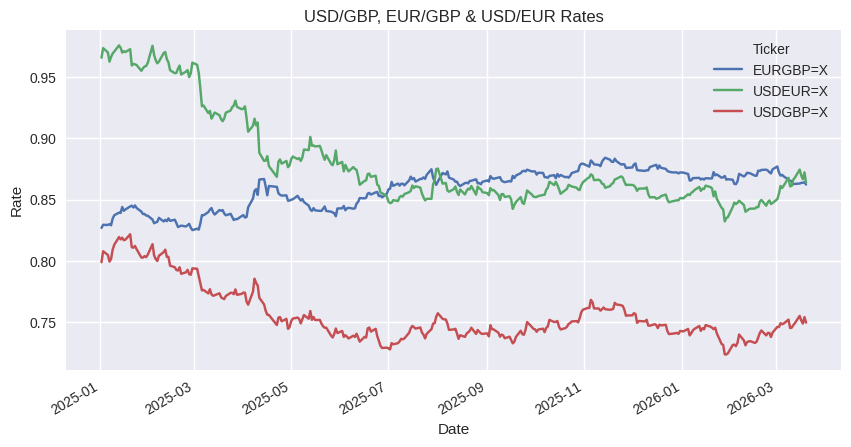

GFX data saved as CSV!


/tmp/ipykernel_443/2198446541.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, progress=False)['Close']


In [16]:
# FX Rates (yfinance supports currency pairs with =X)
fx_tickers = ['USDGBP=X', 'EURGBP=X', 'USDEUR=X']
fx_data = get_stock_data(fx_tickers, start="2025-01-01")
display(fx_data.tail())

fx_data.plot(figsize=(10, 5), title='USD/GBP, EUR/GBP & USD/EUR Rates')
plt.ylabel('Rate')
plt.show()

# Save GFX-focused data]
gfx_df = get_stock_data(['JPM', 'FROTO.IS', 'AAPL', 'MSFT', 'TSLA'])
gfx_df.to_csv(f'gfx_stocks_{datetime.today().strftime("%Y%m%d")}.csv', index=True)
print("GFX data saved as CSV!")

## Interactive Ticker Explorer – BA Dashboard Style

In [21]:
@interact(ticker=Text(value='JPM', description='Enter Ticker (e.g. JPM, FROTO.IS, AAPL, MSFT, or TSLA)'))
def show_ticker(ticker):
    data = yf.Ticker(ticker).history(period="1y")
    print(f"Latest price for {ticker}: {data['Close'].iloc[-1]:.2f}")
    data['Close'].plot(figsize=(10, 5), title=f'{ticker} – 1 Year Price')
    plt.show()

interactive(children=(Text(value='JPM', description='Enter Ticker (e.g. JPM, FROTO.IS, AAPL, MSFT, or TSLA)'),…

In [22]:
# Calculate daily returns
returns = df.pct_change().dropna()
avg_returns = returns.mean() * 252  # Annualized
volatility = returns.std() * np.sqrt(252)

summary = pd.DataFrame({
    'Annual Return': avg_returns,
    'Annual Volatility': volatility,
    'Sharpe Ratio (rf=0)': avg_returns / volatility
}).round(4)
display(summary)

/tmp/ipykernel_443/4002194093.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change().dropna()


,Annual Return,Annual Volatility,Sharpe Ratio (rf=0)
Ticker,,,
AAPL,-0.3713,0.2500,-1.4855
FROTO.IS,0.8480,0.3431,2.4713
JPM,-0.5316,0.2494,-2.1317
MSFT,-0.9130,0.3288,-2.7766
TSLA,-0.7406,0.3411,-2.1711


## Key Takeaways & BA Exercises
- Replaced broken pandas_datareader with reliable yfinance
- Fetched live Global stocks + USD/EUR rates
- Built interactive explorer + returns analysis
- Exercises:
  1. Add volume analysis (`history(period="1y")['Volume']`)
  2. Fetch crypto (e.g., 'BTC-USD') and compare volatility to PSX stocks
  3. Export any DataFrame to Excel (`df.to_excel(...)`)
  4. Create a function that returns a full summary table for any list of tickers
Commit to your fork – this is now a production-ready finance data notebook for JP Morgan BA roles!